#**Data Analytics Project Activity: From Raw Data to Interactive Dashboard**

**Data Analytics Project Activity: From Raw Data to Interactive Dashboard** 🧹

In [ ]:
!pip install -q "kagglehub[pandas-datasets]"
%pip install plotly
%pip install numpy pandas matplotlib seaborn plotly scikit-learn

import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import seaborn as sns

DATASET_HANDLE = "jackdaoud/esports-earnings-for-players-teams-by-game"

df_team = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    DATASET_HANDLE,
    "highest_earning_teams.csv",
)

df_player = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    DATASET_HANDLE,
    "highest_earning_players.csv",
)

df_country = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    DATASET_HANDLE,
    "country-and-continent-codes-list.csv",
)

print("df1 (Teams) shape:", df_team.shape)
print("df2 (Players) shape:", df_player.shape)
print("df3 (Country Codes) shape:", df_country.shape)



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_3864/4013894737.py:11: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df_team = kagglehub.load_dataset(
/tmp/ipykernel_3864/4013894737.py:17: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df_player = kagglehub.load_dataset(
/tmp/ipykernel_3864/4013894737.py:23: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df_country = kagglehub.load_dataset(


df1 (Teams) shape: (928, 6)
df2 (Players) shape: (1000, 8)
df3 (Country Codes) shape: (262, 6)


In [2]:
df_games = pd.read_csv('game_data_by_genre.csv')
df_games #clearning not needed, done/examined via excel

,Genre,Game Name,Earnings,Players,Tournaments
0,Strategy,Age of Empires,965673.48,792,424
1,Strategy,Age of Empires II,5047880.13,2643,2416
2,Strategy,Age of Empires III,146206.97,196,206
3,Strategy,Age of Empires IV,1616476.52,945,684
4,Strategy,Age of Empires Online,12812.98,54,76
...,...,...,...,...,...
685,Music / Rhythm Game,Guitar Hero III: Legends of Rock,36500.00,11,3
686,Music / Rhythm Game,Guitar Hero: World Tour,12000.00,3,1
687,Music / Rhythm Game,Just Dance 2014,0.00,3,1
688,Music / Rhythm Game,osu!,341930.28,1159,286


In [3]:
print(df_player.isna().sum())
print(df_team.isna().sum())
print(df_country.isna().sum())

PlayerId         0
NameFirst        0
NameLast         0
CurrentHandle    0
CountryCode      0
TotalUSDPrize    0
Game             0
Genre            0
dtype: int64
TeamId              0
TeamName            0
TotalUSDPrize       0
TotalTournaments    0
Game                0
Genre               0
dtype: int64
Continent_Name                0
Continent_Code               43
Country_Name                  0
Two_Letter_Country_Code       1
Three_Letter_Country_Code     4
Country_Number                4
dtype: int64


In [4]:
#combined country & continent with player table, Country table no longer needed
df_player["CountryCode"] = df_player["CountryCode"].astype(str).str.upper().str.strip()

df_country["Two_Letter_Country_Code"] = (
    df_country["Two_Letter_Country_Code"].astype(str).str.upper().str.strip()
)


df_player = df_player.merge(
    df_country[["Two_Letter_Country_Code", "Continent_Name", "Country_Name"]],
    left_on="CountryCode",
    right_on="Two_Letter_Country_Code",
    how="left",
)


df_player = df_player.drop(columns=["Two_Letter_Country_Code"])

print("New df_player shape:", df_player.shape)
display(df_player[["CurrentHandle", "CountryCode", "Continent_Name"]].head())

New df_player shape: (1032, 10)


,CurrentHandle,CountryCode,Continent_Name
0,dupreeh,DK,Europe
1,Xyp9x,DK,Europe
2,dev1ce,DK,Europe
3,gla1ve,DK,Europe
4,Magisk,DK,Europe


In [5]:
#show all unique games from the player dataframe
df_player.Game.unique()

<StringArray>
['Counter-Strike: Global Offensive',                           'Dota 2',
                'League of Legends',                         'Fortnite',
                        'Overwatch',                     'Starcraft II',
              'Heroes of the Storm',                             'PUBG',
                   'Arena of Valor',                      'Hearthstone']
Length: 10, dtype: str

In [6]:
#adding new column, Release date for each game
game_release_dates = {
    'Dota 2': '2013-07-09',
    'Counter-Strike: Global Offensive': '2012-08-21',
    'Fortnite': '2017-07-21',
    'League of Legends': '2009-10-27',
    'Overwatch': '2016-05-24',
    'StarCraft II': '2010-07-27',
    'PUBG': '2017-12-21',
    'Hearthstone': '2014-03-11',
    'Arena of Valor': '2016-10-14',
    'Heroes of the Storm': '2015-06-02',
    'StarCraft: Brood War': '1998-11-30',
    'Warcraft III': '2002-07-03',
}


df_player['ReleaseDate'] = pd.to_datetime(
    df_player['Game'].map(game_release_dates),
    errors='coerce'
)



print(df_player['ReleaseDate'].dtype)


df_player = df_player.drop(columns=['CountryCode'])
print(df_player[['Game', 'ReleaseDate']].dtypes)
display(df_player.head())

datetime64[us]
Game                      str
ReleaseDate    datetime64[us]
dtype: object


,PlayerId,NameFirst,NameLast,CurrentHandle,TotalUSDPrize,Game,Genre,Continent_Name,Country_Name,ReleaseDate
0,3883,Peter,Rasmussen,dupreeh,1822989.41,Counter-Strike: Global Offensive,First-Person Shooter,Europe,"Denmark, Kingdom of",2012-08-21
1,3679,Andreas,Højsleth,Xyp9x,1799288.57,Counter-Strike: Global Offensive,First-Person Shooter,Europe,"Denmark, Kingdom of",2012-08-21
2,3885,Nicolai,Reedtz,dev1ce,1787489.88,Counter-Strike: Global Offensive,First-Person Shooter,Europe,"Denmark, Kingdom of",2012-08-21
3,3672,Lukas,Rossander,gla1ve,1652350.75,Counter-Strike: Global Offensive,First-Person Shooter,Europe,"Denmark, Kingdom of",2012-08-21
4,17800,Emil,Reif,Magisk,1416448.64,Counter-Strike: Global Offensive,First-Person Shooter,Europe,"Denmark, Kingdom of",2012-08-21


In [7]:
#changing id to object
df_player.dtypes
df_player['PlayerId'] = df_player['PlayerId'].astype(str)
df_player.dtypes

PlayerId                     str
NameFirst                    str
NameLast                     str
CurrentHandle                str
TotalUSDPrize            float64
Game                         str
Genre                        str
Continent_Name               str
Country_Name                 str
ReleaseDate       datetime64[us]
dtype: object

In [8]:
#changing id to object
df_team.dtypes
df_team['TeamId'] = df_team['TeamId'].astype(str)
df_team.dtypes

TeamId                  str
TeamName                str
TotalUSDPrize       float64
TotalTournaments      int64
Game                    str
Genre                   str
dtype: object

In [9]:
df_country.isnull().sum()

Continent_Name                0
Continent_Code               43
Country_Name                  0
Two_Letter_Country_Code       1
Three_Letter_Country_Code     4
Country_Number                4
dtype: int64

In [10]:
# checking for duplicates
df_player.duplicated().sum()
df_team.duplicated().sum()

np.int64(0)

# Exploratory Data Analysis (EDA)

In [11]:
df_player.describe()

,TotalUSDPrize,ReleaseDate
count,1.032000e+03,932
mean,3.983083e+05,2014-11-30 13:29:36.824034
min,2.417167e+04,2009-10-27 00:00:00
25%,8.418410e+04,2013-07-09 00:00:00
50%,1.720762e+05,2015-06-02 00:00:00
75%,3.902538e+05,2016-10-14 00:00:00
max,6.952597e+06,2017-12-21 00:00:00
std,6.855707e+05,NaN


In [12]:
df_team.describe()

,TotalUSDPrize,TotalTournaments
count,9.280000e+02,928.000000
mean,5.399183e+05,31.696121
std,1.902399e+06,61.075848
min,1.750000e+02,1.000000
25%,3.915000e+04,4.000000
50%,1.165306e+05,11.000000
75%,3.231491e+05,33.000000
max,3.381064e+07,808.000000


In [13]:
#Group Analysis
print('USD price by Genre')
print(df_player.groupby('Genre')['TotalUSDPrize'].sum().reset_index())
print('\nUSD price by Continent')
print(df_player.groupby('Continent_Name')['TotalUSDPrize'].sum().reset_index())



USD price by Genre
                             Genre  TotalUSDPrize
0                    Battle Royale   5.727101e+07
1            Collectible Card Game   1.420638e+07
2             First-Person Shooter   7.325530e+07
3  Multiplayer Online Battle Arena   2.409416e+08
4                         Strategy   2.537982e+07

USD price by Continent
  Continent_Name  TotalUSDPrize
0           Asia   1.827135e+08
1         Europe   1.563520e+08
2  North America   5.703727e+07
3        Oceania   7.999675e+06
4  South America   6.951711e+06


In [14]:
#count of players per game

import plotly.express as px
top_5_games = df_games.groupby('Genre')['Earnings'].sum().reset_index().sort_values('Earnings', ascending=False).head(10)

fig = px.bar(top_5_games, x='Genre', y='Earnings', title='Top 5 best Earning esports games based on genre')
fig.show()

In [15]:
df_games

,Genre,Game Name,Earnings,Players,Tournaments
0,Strategy,Age of Empires,965673.48,792,424
1,Strategy,Age of Empires II,5047880.13,2643,2416
2,Strategy,Age of Empires III,146206.97,196,206
3,Strategy,Age of Empires IV,1616476.52,945,684
4,Strategy,Age of Empires Online,12812.98,54,76
...,...,...,...,...,...
685,Music / Rhythm Game,Guitar Hero III: Legends of Rock,36500.00,11,3
686,Music / Rhythm Game,Guitar Hero: World Tour,12000.00,3,1
687,Music / Rhythm Game,Just Dance 2014,0.00,3,1
688,Music / Rhythm Game,osu!,341930.28,1159,286


In [16]:
#A pie chart of the game and their totalUSDPrize
import plotly.express as px
df_top_10 = df_games.sort_values('Earnings', ascending= False).head(10)

fig = px.pie(df_top_10, values='Earnings', names='Game Name', title='Total USD Prize by Game')
fig.show()

In [17]:

df_trend = df_player.groupby(['ReleaseDate','Game'])['TotalUSDPrize'].sum().reset_index()

fig = px.line(
    df_trend,
    x='ReleaseDate',
    y='TotalUSDPrize',
    hover_data=['Game'],
    title='Total Esports Prize Pools by Game Release Date',
    labels={
        'ReleaseDate': 'Game Release Date',
        'TotalUSDPrize': 'Total Prize Pool (USD)',
        'Game': 'Game Title',
    },
    markers=True,
)

fig.show()


In [18]:
import matplotlib.pyplot as plt


fig = px.box(df_player, x='Continent_Name', y='TotalUSDPrize', title='Box Plot of Conteinent vs Total USD Prize', range_y=[0, 6200000])
fig.update_xaxes(title_text='Game')
fig.update_yaxes(title_text='Total USD Prize')
fig.show()


/tmp/ipykernel_3864/1666387983.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Number of Games', y='Genre', data=games_per_genre, palette='viridis')


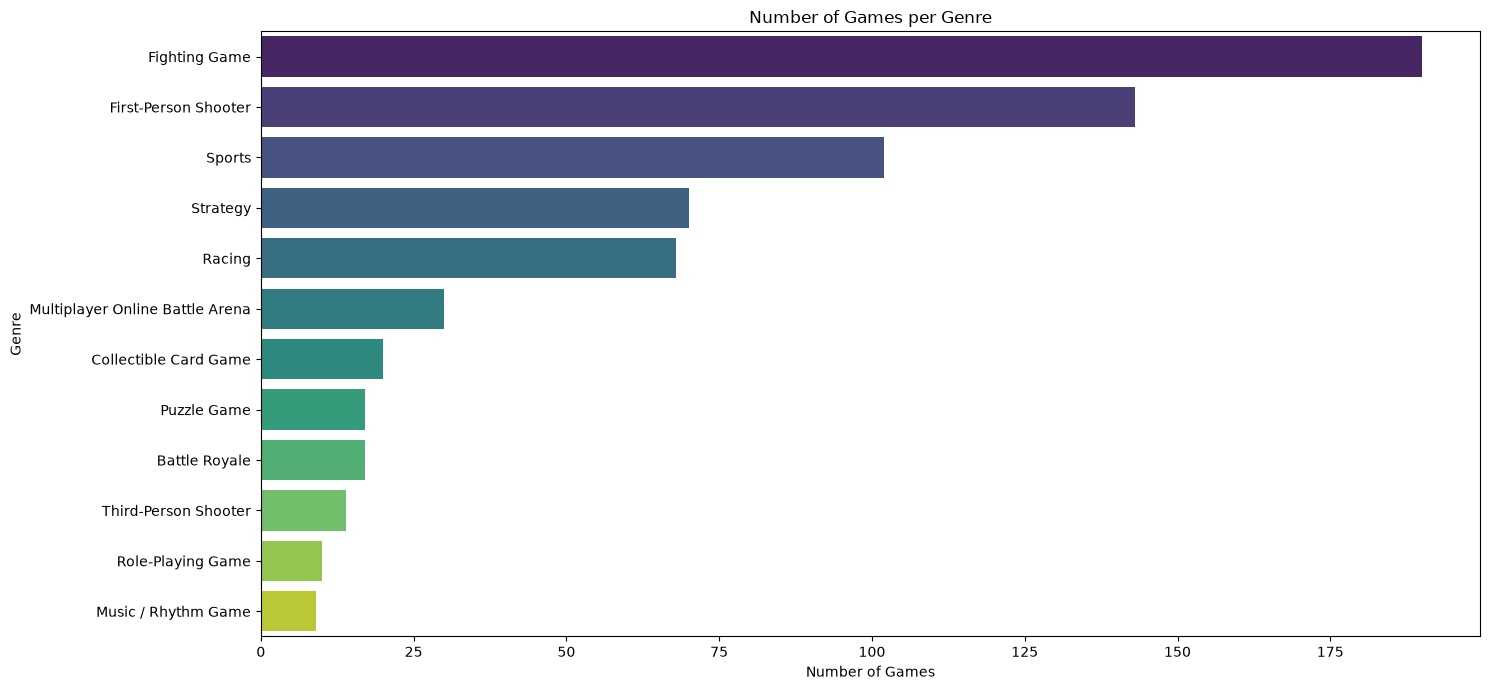

In [19]:
games_per_genre = df_games['Genre'].value_counts().reset_index()
games_per_genre.columns = ['Genre', 'Number of Games']

plt.figure(figsize=(15, 7))
sns.barplot(x='Number of Games', y='Genre', data=games_per_genre, palette='viridis')
plt.title('Number of Games per Genre')
plt.xlabel('Number of Games')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

In [42]:
import plotly.graph_objects as go

# KPI Cards
fig.add_trace(go.Indicator(
    mode = "number",
    value = df_player['TotalUSDPrize'].sum(),
    number  = {'prefix': '$', 'valueformat':',.0f'},
    title = {'text': 'Total Prize Pool (Sales)'},
    domain = {'row': 0, 'column': 0}
))

fig.add_trace(go.Indicator(
    mode = "number",
    value = len(df_player),
    number  = {'valueformat':',.0f'},
    title = {'text': 'Total Records (Profit/Volume)'},
    domain = {'row': 0, 'column': 1}
))

fig.add_trace(go.Indicator(
    mode = "number",
    value = df_player['TotalUSDPrize'].mean(),
    number  = {'prefix': '$', 'valueformat':',.0f'},
    title = {'text': 'Avg Value per Entry'},
    domain = {'row': 0, 'column': 2}
))

games = ['All'] + sorted(df_player['Game'].dropna().unique().tolist())
buttons = []

for game in games:
    if game == 'All':
        filtered = df_player
    else:
        filtered = df_player[df_player['Game'] == game]

    tot = filtered['TotalUSDPrize'].sum()
    cnt = len(filtered)
    avg = filtered['TotalUSDPrize'].mean() if cnt > 0 else 0

    buttons.append(dict(
        method='update',
        label=game,
        args=[
            {'value': [tot, cnt, avg]},
            {'title': f'Esports Dashboard - Game: {game}'}
        ]
    ))

fig.update_layout(
    grid={'rows':2, 'columns':3, 'pattern':'independent'},
    updatemenus=[
        dict(
            buttons=buttons,
            direction='down',
            showactive=True,
            x=0.0,
            xanchor='left',
            y=1.75,
            yanchor='top'
        )
    ],
    title_text="Esports Dashboard - Game: All",
    height=450,
    margin=dict(l=30, r=30, t=100, b=30),
    yaxis=dict(domain=[0, 0.65]),
     xaxis=dict(title='Release Year')
 )

fig.show(config={'toImageButtonOptions': {'format': 'png'}, 'displaylogo':False})